Trend on MAR_EC_Earth3

1. Environment

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import calendar as cld
import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator
from matplotlib.colors import BoundaryNorm
from scipy import stats
import os
import gdown
from tqdm import tqdm

In [2]:
# function for seasonal mean (from Ian)
def season_mean(ds, calendar="standard"):
    #make a DataArray with the season of each day
    seas_array = ds.time.dt.season
    
    # count days in winter season (varies with leap years)
    nb_DJF = seas_array.str.count('DJF').sum()
    
    wgt_DJF = 1/nb_DJF.values.item()
    wgt_MAM = 1/(31+30+31)
    wgt_JJA = 1/(30+31+31)
    wgt_SON = 1/(30+31+30)

    weight = seas_array.str.replace('DJF',str(wgt_DJF)).str.replace('MAM',str(wgt_MAM)).str.replace('JJA',str(wgt_JJA)).str.replace('SON',str(wgt_SON))
    weight = weight.astype('float')
    
    # Test that the sum of the weights for each season is 1.0
    np.testing.assert_allclose(weight.groupby("time.season").sum().values, np.ones(4))

    # Calculate the weighted average
    return (ds * weight).groupby("time.season").sum(dim="time")


In [3]:
def findXYGlacioclim (lonGla,latGla) :
# Find the speed at a certain lat/lon point.
    #Find the index of the grid point nearest a specific lat/lon.   
    abslat = np.abs(dsTopo.LAT-latGla)
    abslon = np.abs(dsTopo.LON-lonGla)
    c = np.maximum(abslon, abslat)
    # Return the grid point coordinates (x,y)
    ([xloc], [yloc]) = np.where(c == np.min(c))
    return (xloc, yloc) #([xloc], [yloc])
#print([xloc], [yloc]) 

In [4]:
# To print details (information on dataset etc)
verbose=True #False

In [5]:
# Where are the data files?
name_GCM = 'EC-Earth3'
scenario = 'HIST' #'SSP245'
sim = 'EUe'
path_MAR= "/bettik/beaumetj/MARout/MAR-"+name_GCM+"/"
path_GCM= "/bettik/peyaudv/MAR_GCMs/GCM/"+name_GCM+"/"

data_freq = 'monthly'
data_freq_prefix = 'MON' # ICE for daily, MON for monthly

first_year = 2015
last_year = 2100

In [6]:
# Domain
lon1=60;lon2=110;lat1=25;lat2=45    # Domain study: HMA
latS,latN,lonW,lonE = 42,49, 2,18   # Greater Alpine region 
latS,latN,lonW,lonE = 44,46.2, 6,8  # French Alpes

In [7]:
# location study
glacioClim=[["Argentiere",6.93,45.9], ["Mer de Glace",6.97,45.95], ["Gebroulaz",6.61,45.28], ["Saint Sorlin",6.63,45.15], ["Glacier Blanc",6.37,44.93]]
#ax.plot(6.93,45.9, marker='o',color='black') # Argentiere 45° 57′ 37″ nord, 6° 58′ 46″ est
#ax.plot(6.97,45.95, marker='o',color='black') # Mer de Glace 45° 54′ 10″ nord, 6° 56′ 40″ est
#ax.plot(6.61,45.28, marker='o',color='black') # Gebroulaz 45° 17′ 20″ nord, 6° 37′ 57″ est
#ax.plot(6.63,45.15, marker='o',color='black') # Pic Etendard 45° 09′ 16″ nord, 6° 08′ 38″ est
#ax.plot(6.37,44.93, marker='o',color='black') # Glacier Blanc 44° 56′ 25″ nord, 6° 22′ 50″ est

In [ ]:
glacioClXY=glacioClim
for i in range(len(glacioClim)):
    #print (i,glacioClim[i][0])
    glacioClXY[i][1],glacioClXY[i][2] = findXYGlacioclim (glacioClim[i][1],glacioClim[i][2])
    
print(glacioClXY)

In [10]:
# Format for what ???
normal_format = {'gridlinewidth':0.1, 'gridcolor':'gray8', 'gridalpha':0.5, 'coast':True,'borders':True ,'reso':'hi', 'labels':True,
                 'lonlines':2, 'latlines':2, 'abc':False, 'latlim':[43.,48.5],'lonlim':[4.,16.]}
multiplot_format = {'gridlinewidth':0.1, 'gridcolor':'gray8', 'gridalpha':0.5, 'coast':True,'borders':True ,'reso':'hi', 'labels':False,
                    'lonlines':2, 'latlines':2, 'abc':False, 'latlim':[43.,48.5],'lonlim':[4.,16.]}

# Topo MAR
#dsTopo = xr.open_dataset('/bettik/beaumetj/MARout/MAR-ERA-20C/MARgrid_EUf.nc')

year=first_year
file1=path_GCM+'tas_Amon_EC-Earth3_ssp245_r1i1p1f1_gr_'+str(year)+'01-'+str(year)+'12.nc' 
print (file1)
dsTopo = xr.open_dataset(file1)

imin = 32 ; imax = -30
jmin = 20 ; jmax = -15
lon = dsTopo.lon #dsTopo.LON[jmin:jmax,imin:imax]
lat = dsTopo.lat #dsTopo.LAT[jmin:jmax,imin:imax]

H = np.array(dsTopo.height) # (dsTopo.SH[jmin:jmax,imin:imax]) # Topo

seasons = ['DJF','MAM','JJA', 'SON']

/bettik/peyaudv/MAR_GCMs/GCM/EC-Earth3/tas_Amon_EC-Earth3_ssp245_r1i1p1f1_gr_201501-201512.nc


In [41]:
#print (dsTopo.lon[jmin,imin],dsTopo.lat[jmin,imin])

In [10]:
def detect_glacier(H):
    nlat,nlon = np.shape(H)
    mask = np.bool_(np.zeros((nlat,nlon)))
    r = 4
    for j in range(r,nlat-r):
        for i in range(r,nlon-r):
            mask[j,i] = np.logical_and(H[j,i]>360 ,np.any(H[j-r:j+r,i-r:i+r]>1300))
            # mask[j,i] = np.std(H[j-r:j+r,i-r:i+r])>200
    return mask

In [11]:
dsTopo

<xarray.Dataset> Size: 6MB
Dimensions:    (time: 12, bnds: 2, lat: 256, lon: 512)
Coordinates:
  * time       (time) datetime64[ns] 96B 2015-01-16T12:00:00 ... 2015-12-16T1...
  * lat        (lat) float64 2kB -89.46 -88.77 -88.07 ... 88.07 88.77 89.46
  * lon        (lon) float64 4kB 0.0 0.7031 1.406 2.109 ... 357.9 358.6 359.3
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 192B ...
    lat_bnds   (lat, bnds) float64 4kB ...
    lon_bnds   (lon, bnds) float64 8kB ...
    tas        (time, lat, lon) float32 6MB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time:            0.0
    comment:                Production: Thomas Reerink at KNMI
    contact:                cmip6-data@ec-earth.org
    ...                     ...
    license:                CMIP6 model data produced by EC-Earth-Consortium ...
    cmor_version:           3.5.0
    tracking_id:            hdl:21.14100/083a5f5a-0429-4527-8c93-1bbdb088a476
    branch_time_in_child:   60265.0D
    branch_time_in_parent:  60265.0D
    history:                2019-09-26T21:39:34Z ; CMOR rewrote data to be co...

In [12]:
dsTopo.LON
#xarray.DataArray 'LON'  y: 126x: 201

NameError: name 'dsTopo' is not defined

IndexError: too many indices

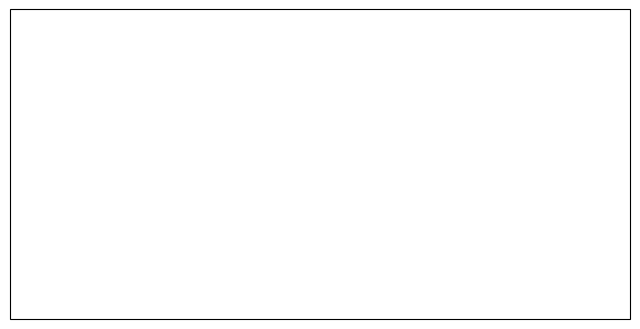

In [12]:
# traduction par ChatGPT d'un script de Ian utilisant proplot pour utiliser matplotlib
#(https://github.com/Ian-CD/PhD/blob/master/Seasonal_Climate.ipynb)

# équivalent du rc figure.facecolor
plt.rcParams['figure.facecolor'] = 'white'

# Colormap
colors_land = plt.cm.terrain(np.linspace(0.25, 1, 256))
cmap_land = plt.matplotlib.colors.ListedColormap(colors_land)

# --- Niveaux réguliers ---
vmin = np.nanmin(dsTopo.height)
vmax = np.nanmax(dsTopo.height)
levels = np.linspace(vmin, vmax, 17)  # 17 niveaux
norm = BoundaryNorm(levels, ncolors=cmap_land.N, clip=True)

# Création figure+axes avec projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh
m = ax.pcolormesh(
    dsTopo.lon, dsTopo.lat, dsTopo.height[:,:],
    cmap=cmap_land,
    shading='auto' 
)

# Colorbar
#cbar = plt.colorbar(m, ax=ax)
cbar = plt.colorbar(m, ax=ax, boundaries=levels, ticks=levels) # 17 niveaux reguliers
cbar.set_label('m.a.s.l.', fontsize='x-large')
cbar.ax.tick_params(labelsize='large')

## Points
#ax.plot(ds.LON[60,100], ds.LAT[60,100], 'ro', markersize=2, transform=ccrs.PlateCarree())
#ax.plot(7.2, 44.6, 'rx', markersize=3, transform=ccrs.PlateCarree())
#ax.plot(ds.LON[70,45], ds.LAT[70,45], 'rx', markersize=5, transform=ccrs.PlateCarree())

# Limites carte
ax.set_extent([0., 20., 40., 51.], crs=ccrs.PlateCarree())

# Ajout océans (équivalent ocean=True + oceancolor)
ax.add_feature(cfeature.OCEAN, facecolor='royalblue')
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')

# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

# Format normal: titres, grilles, ticks, etc.
# (il faut expliciter car ProPlot fait beaucoup automatiquement)
ax.gridlines(draw_labels=True)

plt.show()

#Notes de traduction

#    proj='cyl' → ccrs.PlateCarree().

#    ax.format() n’existe pas : on remplace par set_extent, gridlines, add_feature, etc.

#    ocean=True → ax.add_feature(cfeature.OCEAN).

#    pcolormesh(..., levels=17) n’est pas un paramètre dans matplotlib pour pcolormesh.
#    niveaux réguliers via norm=BoundaryNorm.

2. Test opening temperature 1 data file

In [28]:
# Information on the first file
year=2015#first_year
#file1=path_MAR+'/'+scenario+'/'+data_freq+'/'+data_freq_prefix+'.'+name_GCM+'_'+scenario+'.'+sim+'.TTz.'+str(year)+'.nc'

file1=path_GCM+'tas_Amon_EC-Earth3_ssp245_r1i1p1f1_gr_'+str(year)+'01-'+str(year)+'12_EU.nc'
#file1='/bettik/peyaudv/MAR_GCMs/GCM/EC-Earth3/tas_Amon_EC-Earth3_ssp245_r1i1p1f1_gr_201501-201512_EU.nc '
print(file1)
ds = xr.open_dataset(file1) # Alternative #ds = xr.open_dataset(os.path.join(path,file))

/bettik/peyaudv/MAR_GCMs/GCM/EC-Earth3/tas_Amon_EC-Earth3_ssp245_r1i1p1f1_gr_201501-201512_EU.nc


In [29]:
#ds # To print the header of the dataset 
#ds.bnds

In [30]:
#ds.tas.mean("time")[:,:]  # xarray.DataArray 'tas' lat: 256lon: 512

2.1 Plot map of temperature

Text(0.5, 1.0, 'Mean Temperature (tas_Amon_EC-Earth3_ssp245_r1i1p1f1_gr_201501-201512_EU.nc)')

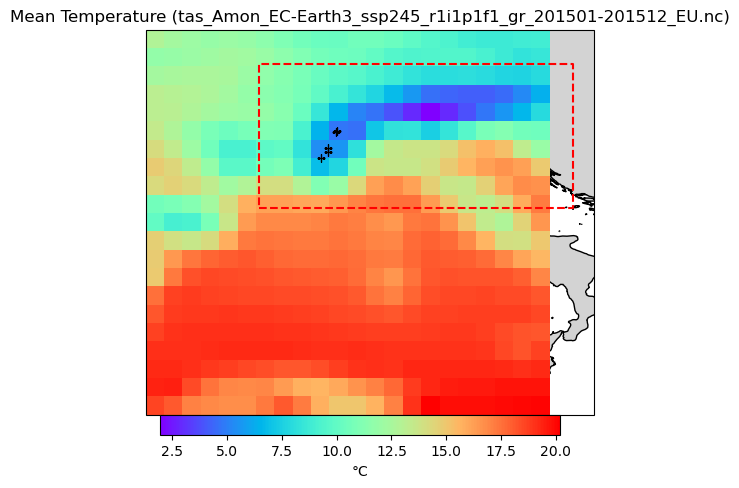

In [31]:
# Creation figure+axes with projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh
m = ax.pcolormesh(
    ds.lon, ds.lat, ds.tas.mean("time")[:,:]-273.15,
    cmap='rainbow', shading='auto' 
)
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

# Position des glaciers
for i in range(len(glacioClim)):
    #print (i,glacioClim[i][0])
    ax.plot(glacioClim[i][1],glacioClim[i][2], marker='+',color='black')

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='°C')

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
ax.set_title(f'Mean Temperature ({JustFilename})')

2.2 extract and temperature at Glacier location

In [17]:
xloc,yloc = glacioClim[i][1],glacioClim[i][2]
ds.tas.mean("time")[:,:].sel(lon=xloc,lat=yloc,method='nearest')

<xarray.DataArray 'tas' ()> Size: 4B
array(278.57654, dtype=float32)
Coordinates:
    lat      float64 8B 45.26
    lon      float64 8B 6.328
    height   float64 8B ...

In [60]:
#ds.time

In [66]:
#Plot temperature pour 1 glacier
#Ttime= ds.TTz.sel(x=xloc,y=yloc,ztqlev=2,method='nearest')
#plt.plot(ds.time,Ttime)

In [20]:
print(glacioClim[0][:])
ds.tas.mean("time")

['Argentiere', 6.93, 45.9]


<xarray.DataArray 'tas' (lat: 256, lon: 512)> Size: 524kB
array([[234.20435, 234.19478, 234.18526, ..., 234.22615, 234.21892,
        234.21162],
       [234.34094, 234.32625, 234.31154, ..., 234.37567, 234.36409,
        234.35254],
       [234.3218 , 234.297  , 234.27223, ..., 234.42096, 234.38792,
        234.35484],
       ...,
       [259.82507, 259.83505, 259.845  , ..., 259.78323, 259.79718,
        259.81116],
       [259.5884 , 259.59525, 259.60214, ..., 259.5677 , 259.57462,
        259.5815 ],
       [259.44577, 259.44882, 259.45193, ..., 259.43704, 259.43994,
        259.44284]], shape=(256, 512), dtype=float32)
Coordinates:
  * lat      (lat) float64 2kB -89.46 -88.77 -88.07 -87.37 ... 88.07 88.77 89.46
  * lon      (lon) float64 4kB 0.0 0.7031 1.406 2.109 ... 357.9 358.6 359.3
    height   float64 8B ...

Text(0.5, 0.98, 'Temperature at 4 locations (tas_Amon_EC-Earth3_ssp245_r1i1p1f1_gr_201501-201512.nc)')

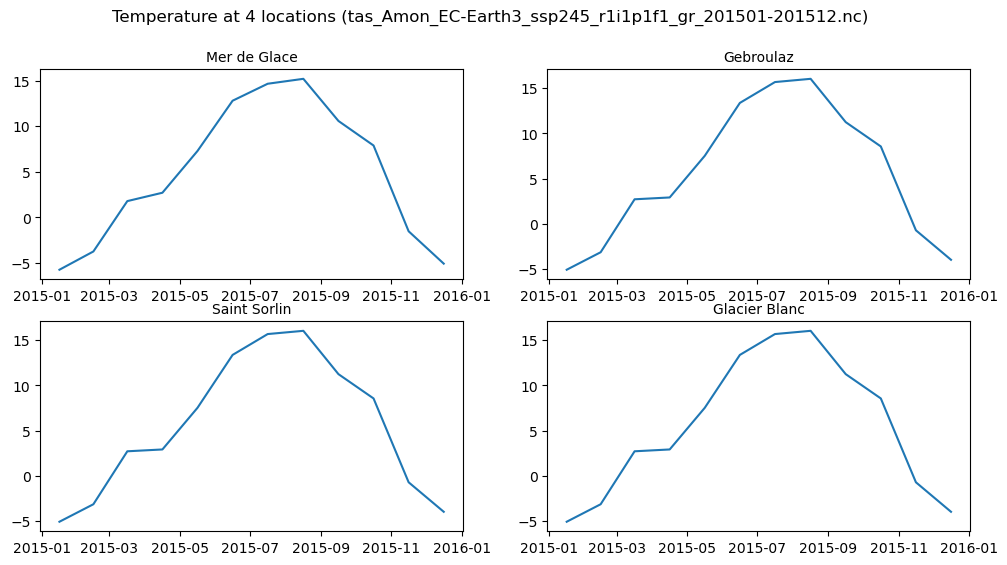

In [21]:
#Plot temperature pour 4 glacier
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs = axs.ravel()


for i, ax in enumerate(axs):
    glaName,xloc,yloc = glacioClim[i+1][:] # i+1 because 5 glaciers and 2 first are in same pixel (Arg and MdG)
    #print(glaName,xloc,yloc)
    Ttime= ds.tas.sel(lon=xloc,lat=yloc,method='nearest')-273.15
    ax.plot(ds.time,Ttime)
    ax.set_title(glaName,fontsize=10)
fig.suptitle(f"Temperature at 4 locations ({JustFilename})", fontsize=12)

In [25]:
seasonal_mean = ds.tas.groupby("time.season").mean(dim="time")[:,:].sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))

In [26]:
seasonal_mean.shape
#seasonal_mean

(4, 256, 512)

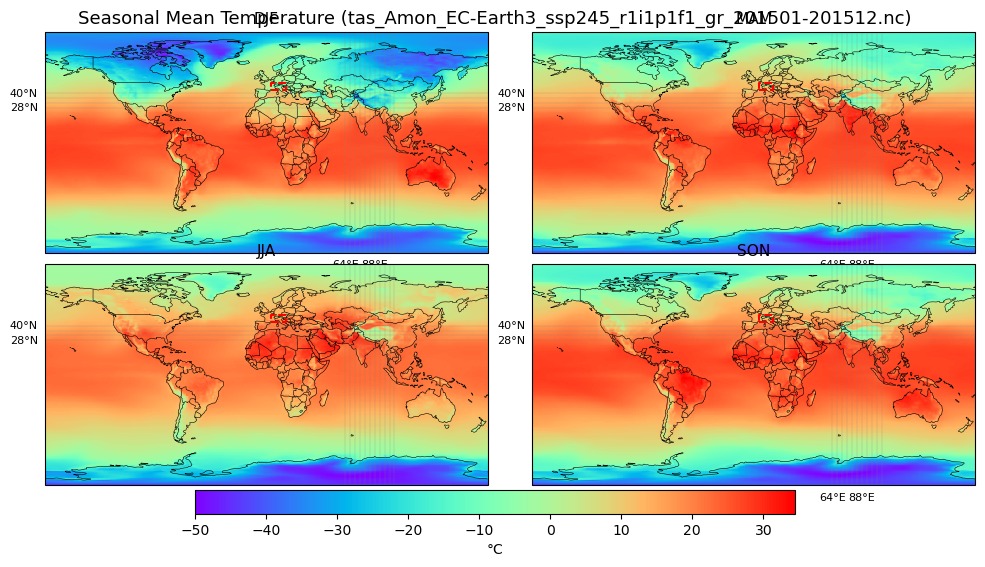

In [27]:
proj = ccrs.PlateCarree()

# Fixed color levels
levels = np.arange(-32, 32+2, 2)
cmap, quality = plt.get_cmap('rainbow'), 100
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

fig, axs = plt.subplots(2, 2, figsize=(12, 6),
                        subplot_kw={'projection': proj},dpi=quality)
axs = axs.ravel()

for i, ax in enumerate(axs):
    pcm = ax.pcolormesh(ds.lon, ds.lat, seasonal_mean[i]-273.15, 
    cmap='rainbow', shading='auto'
)
 #                       cmap=cmap, shading='auto', norm=norm)
    
    # Geographic features
    ax.add_feature(cfeature.COASTLINE, lw=0.4)
    ax.add_feature(cfeature.BORDERS, lw=0.4)
    # Tracé du polygone en pointillés rouge
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
    
#    ax.set_extent([lon1, lon2, lat1, lat2-3])
    
    # Gridlines at specified coordinates with labels
    gl = ax.gridlines(draw_labels=True, lw=0.3, color='gray', alpha=0.5)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = gl.ylabel_style = {'size': 8}
    
    gl.xlocator = FixedLocator(lon_ticks)
    gl.ylocator = FixedLocator(lat_ticks)
    
    ax.set_title(seasonal_mean.season.data[i], fontsize=11)

# Tight layout
plt.subplots_adjust(wspace=0.1, hspace=0.01)

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', label='°C')

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
fig.suptitle(f"Seasonal Mean Temperature ({JustFilename})", fontsize=13, y=0.91)
plt.show()

In [118]:
# define a function to compute seasonal mean
# Taking into account the differet number of days per months
def season_mean(dataset, calendar="standard"):
    # Make a DataArray with the number of days in each month, size = len(time)
    month_length = dataset.time.dt.days_in_month

    # Calculate the weights by grouping by 'time.season'
    weights = (
        month_length.groupby("time.season") / month_length.groupby("time.season").sum()
    )

    # Test that the sum of the weights for each season is 1.0
    np.testing.assert_allclose(weights.groupby("time.season").sum().values, np.ones(4))

    # Calculate the weighted average
    return (dataset * weights).groupby("time.season").sum(dim="time")

In [122]:
### Ne marche pas

# Computing seasonal mean and ordering properly the seasons
#seasonal_mean=season_mean(ds).sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))

3. Open temperature data file

In [39]:
# TTz
T_month = np.zeros(((last_year-first_year+1),12, 256,512))

# 4 dimensions : year, month, AND lon, lat ???  
T_month.shape

(86, 12, 256, 512)

In [43]:
for year in list(range(first_year,last_year+1)):
    print(year,end=' ')
 #   if year == 1985 or year == 2071:
 #       continue
    #hist_path = '/bettik/beaumetj/MARout/MAR-'+name_GCM+'/HIST/'+data_freq+'/'+data_freq_prefix+'.'+name_GCM+'_HIST.'+sim+'.TTz.'+str(year)+'.nc'
    #ssp245_path = '/bettik/beaumetj/MARout/MAR-'+name_GCM+'/SSP245/'+data_freq+'/'+data_freq_prefix+'.'+name_GCM+'_SSP245.'+sim+'.TTz.'+str(year)+'.nc'
    ssp245_path = path_GCM+'tas_Amon_EC-Earth3_ssp245_r1i1p1f1_gr_'+str(year)+'01-'+str(year)+'12.nc'
    if year <2015:
        ds_var = xr.open_dataset(hist_path)
    else:
        #ds_T = xr.open_dataset('/bettik/beaumetj/MARout/MAR-EC-Earth3/SSP245/monthly/MON.EC-Earth3_SSP245.EUe.TTz.'+str(year)+'.nc')
        ds_var = xr.open_dataset(ssp245_path)
        print("ssp245_path")
    T_month[year-1961]=ds_var.tas[:,:]
    seasonal_mean_year=season_mean(ds_var.tas.sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season'])))

2015 ssp245_path


ValueError: Dimensions {'season'} do not exist. Expected one or more of FrozenMappingWarningOnValuesAccess({'time': 12, 'lat': 256, 'lon': 512})

In [117]:
T_month

array([[[[ 9.04697704e+00,  9.12078381e+00,  9.18231106e+00, ...,
           9.86959934e+00,  9.87028599e+00,  9.87290859e+00],
         [ 8.95572472e+00,  9.02752018e+00,  9.07281017e+00, ...,
           9.82810020e+00,  9.82880878e+00,  9.82053280e+00],
         [ 8.84529591e+00,  8.91236877e+00,  8.98299408e+00, ...,
           9.78627682e+00,  9.77077198e+00,  9.75996304e+00],
         ...,
         [-5.36291957e-01, -7.30008006e-01, -8.70311856e-01, ...,
          -4.40100050e+00, -4.58652020e+00, -4.57072210e+00],
         [-3.55133861e-01, -8.41346920e-01, -1.24703872e+00, ...,
          -4.49817848e+00, -4.60968494e+00, -4.57047558e+00],
         [-4.64437634e-01, -6.49384618e-01, -1.07387543e+00, ...,
          -4.25332069e+00, -4.38688374e+00, -4.46512079e+00]],

        [[ 1.06346188e+01,  1.06913185e+01,  1.07415924e+01, ...,
           9.22295952e+00,  9.23397923e+00,  9.23793030e+00],
         [ 1.05698452e+01,  1.06230850e+01,  1.06648798e+01, ...,
           9.18155098e

Text(0.5, 1.0, 'Mean Temperature (MON.EC-Earth3_HIST.EUe.TTz.1961.nc)')

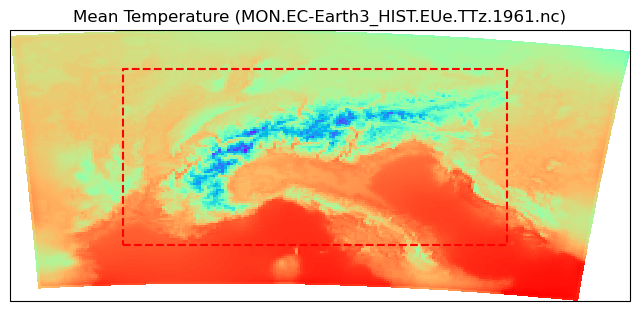

In [120]:
# First : Figure avec 1 fichier xarray aray ds.TTz !!! Rien de neuf c'est deja fait au dessus

# Création figure+axes avec projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh
m = ax.pcolormesh(
    dsTopo.LON, dsTopo.LAT, ds.TTz.mean("time")[0],
    cmap='rainbow',
    shading='auto' 
)

# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
ax.set_title(f'Mean Temperature ({JustFilename})')

TypeError: 'str' object cannot be interpreted as an integer

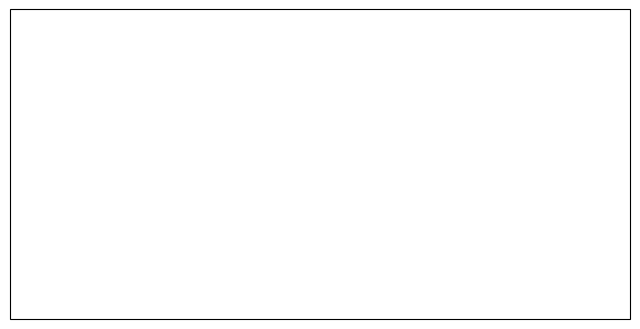

In [116]:
# Création figure+axes avec projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh
m = ax.pcolormesh(
    dsTopo.LON, dsTopo.LAT, T_month.mean("time")[0],
    cmap='rainbow',
    shading='auto' 
)

# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
ax.set_title(f'Mean Temperature ({JustFilename})')

In [97]:
# Have we the same figure using 1 file and the corresponding data in array T_month ? Yes

4. Computing seasonal means

In [148]:
# Period over which computing the trends
date1=datetime.date(year=first_year,month=1,day=1)
date2=datetime.date(year=last_year,month=12,day=31)
datesY=pd.date_range(start=date1, end=date2, freq='Y') # years
datesM=pd.date_range(start=date1, end=date2, freq='M') # months
datesM.year

/tmp/ipykernel_3249012/248196427.py:4: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  datesY=pd.date_range(start=date1, end=date2, freq='Y') # years
/tmp/ipykernel_3249012/248196427.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datesM=pd.date_range(start=date1, end=date2, freq='M') # months


Index([1961, 1961, 1961, 1961, 1961, 1961, 1961, 1961, 1961, 1961,
       ...
       2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015],
      dtype='int32', length=660)

In [146]:
# Dans HMA_climate_trends_CRU : il n'y a qu'un fichier -> 1 ds
# Ici j'ai copié des data de plusieurs fichier dans une array (xarray)
# Ceci est un test pour temperatures mensuelles:
#T_loc = T_month[:,:,10,20]
#T_loc # OK
#T_loc
#result = T_loc.reshape(660)
#plt.plot(dates,result)

# Ceci est un test pour temperatures annuelles:
T_loc = T_month[:,:,10,20]
result = np.average(T_loc, axis=1)
result

array([12.92279567, 11.63018786, 12.82577725, 11.46100963, 11.78881342,
       12.64101669, 11.9815317 , 11.90298933, 12.00294218, 12.78837806,
       12.52721437, 12.21951015, 13.02961132, 12.06301196, 12.33689674,
       12.8270874 , 13.25031106, 13.133087  , 12.42492173, 13.40213915,
       12.18937924, 12.93008614, 12.48102617, 13.3161549 ,  0.        ,
       12.33910334, 12.65615298, 12.12578901, 11.96317118, 11.65335902,
       13.00490452, 11.68479968, 11.24595401, 12.96436767, 13.11399317,
       12.47568423, 12.53772229, 12.79992203, 13.43903021, 12.4754137 ,
       13.36887678, 13.27755857, 12.9667331 , 13.14969256, 13.01799119,
       12.99519769, 13.54149195, 13.89417585, 13.50056348, 12.60405626,
       12.85434671, 12.74998956, 13.78786753, 13.97851576, 13.50195342])

Text(0.5, 0.98, 'Temperature at 4 locations (MON.EC-Earth3_HIST.EUe.TTz.1961.nc)')

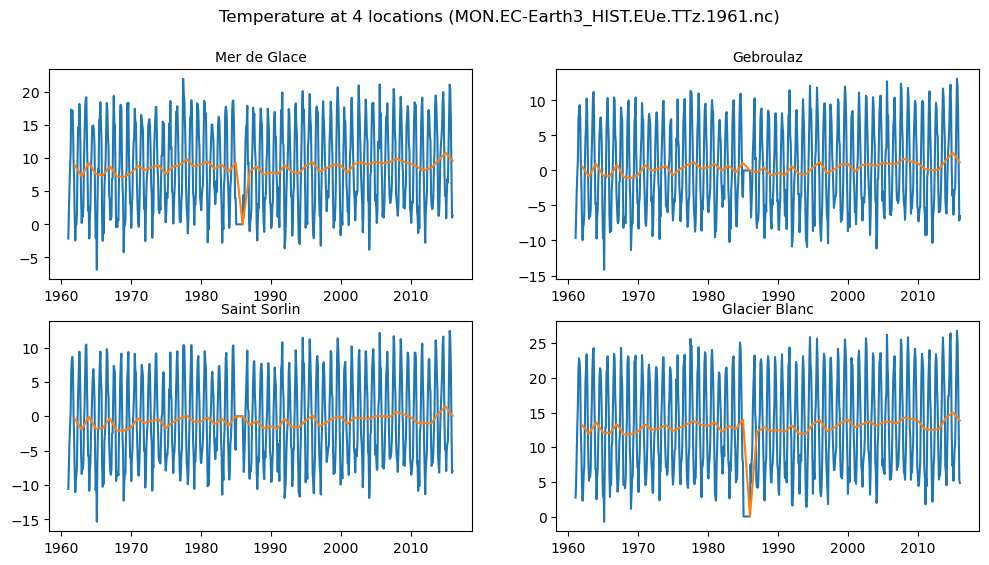

In [149]:
#Plot temperatures mensuelles pour 4 glacier
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs = axs.ravel()

for i, ax in enumerate(axs):
    glaName,xloc,yloc = glacioClXY[i+1][:] # i+1 because 5 glaciers and 2 first are in same pixel (Arg and MdG)
    #print(glaName,xloc,yloc)
    T_loc = T_month[:,:,xloc,yloc]
    ax.plot(datesM,T_loc.reshape(660))        # T mensuelles
    ax.plot(datesY,np.average(T_loc, axis=1)) # T annuelles
    ax.set_title(glaName,fontsize=10)
fig.suptitle(f"Temperature at 4 locations ({JustFilename})", fontsize=12)

In [138]:
# Temperature in time (monthly) for 1 location
#Ttime= ds.TTz.sel(x=xloc,y=yloc,ztqlev=2,method='nearest')
#Ttime

In [115]:
plt.plot(dates,TTz.sel(x=xloc,y=yloc,ztqlev=2,method='nearest'))

NameError: name 'TTz' is not defined

In [ ]:
#Plot temperature pour 4 glacier
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs = axs.ravel()

for i, ax in enumerate(axs):
    glaName,xloc,yloc = glacioClXY[i+1][:] # i+1 because 5 glaciers and 2 first are in same pixel (Arg and MdG)
    #print(glaName,xloc,yloc)
    Ttime= ds.TTz.sel(x=xloc,y=yloc,ztqlev=2,method='nearest')
    ax.plot(ds.time,Ttime)
    ax.set_title(glaName,fontsize=10)

In [106]:
Ttime

<xarray.DataArray 'TTz' (time: 12)> Size: 48B
array([ 0.723263,  2.92838 ,  7.960557, 12.44617 , 16.008818, 21.611305,
       23.791677, 23.119934, 19.87195 , 11.262476,  6.911168,  1.667901],
      dtype=float32)
Coordinates:
    x        float32 4B 49.0
    y        float32 4B 63.0
    ztqlev   float32 4B 2.0
  * time     (time) datetime64[ns] 96B 1961-01-16T12:00:00 ... 1961-12-16T12:...
Attributes:
    standard_name:  Temperature
    long_name:      Temperature
    units:          C
    actual_range:   [-27.90149   14.558552]

In [103]:
temp_loc.where(Temp['time.season'] == 'DJF').groupby('time.year').mean(dim='time')

AttributeError: 'list' object has no attribute 'where'

In [88]:
# Figures parameters:
quality=200
proj = ccrs.PlateCarree()

In [89]:
T_month.shape[0] # ????????????

55

In [90]:
for i in range(T_month.shape[0]):
    year = i+1961
    # print (i,year) 
    seasonal_mean_year=season_mean(T_month[i]).sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))
#seasonal_mean_year=season_mean(ds_T.TTz.sel(ztqlev=2)).sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))


AttributeError: 'numpy.ndarray' object has no attribute 'time'

4.1 Trend at glaciers location

In [100]:
temp_loc=[0]*5
temp_loc[4]=[1,2,3,4]
temp_loc

[0, 0, 0, 0, [1, 2, 3, 4]]

In [101]:
lon_loc,lat_loc = glacioClim[0][1],glacioClim[0][2] # Argentiere
print(lon_loc,lat_loc)

65 66


In [102]:
temp_loc[0]=T_month.sel(lon=lon_loc, lat=lat_loc, method="nearest")

AttributeError: 'numpy.ndarray' object has no attribute 'sel'

In [93]:
# Extraction of the data at the point
temp_loc=[0] * 5 
lon_loc,lat_loc = glacioClim[0][1],glacioClim[0][2] # Argentiere
print(lon_loc,lat_loc)
#temp_loc[0]=T_month.sel(lon=lon_loc, lat=lat_loc, method="nearest")

65 66


In [95]:
temp_loc.where(Temp['time.season'] == 'DJF').groupby('time.year').mean(dim='time')

AttributeError: 'list' object has no attribute 'where'

In [94]:
# Seasonal spatial data

seasonal_T_loc [:,0] = temp_loc.where(Temp['time.season'] == 'DJF').groupby('time.year').mean(dim='time')
seasonal_T_loc [:,1] = temp_loc.where(Temp['time.season'] == 'MAM').groupby('time.year').mean(dim='time')
seasonal_T_loc [:,2] = temp_loc.where(Temp['time.season'] == 'JJA').groupby('time.year').mean(dim='time')
seasonal_T_loc [:,3] = temp_loc.where(Temp['time.season'] == 'SON').groupby('time.year').mean(dim='time')

AttributeError: 'list' object has no attribute 'where'

4.2 Trend map